1️⃣ Importación de librerías y carga del dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Configuración visual
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)

# Carga del dataset
df = pd.read_csv("C:/Users/brent/Downloads/archivos/dataset_fiscal_provincial_2020_2025.csv")

df.head()

,anio,provincia,coef_coparticipacion,pbi_provincial,recaudacion_total_prov,recaudacion_iva_prov,recaudacion_ganancias_prov,presion_tributaria,tasa_empleo_formal,tasa_informalidad
0,2020,Buenos Aires,0.213,133037.943951,1.620406e+06,341661.260943,277483.238663,12.18,19.4,8.525
1,2020,Catamarca,0.026,16239.373440,1.977960e+05,41705.130444,33871.193452,12.18,19.4,8.525
2,2020,Chaco,0.084,52465.668037,6.390332e+05,134739.652203,109430.009614,12.18,19.4,8.525
3,2020,Chubut,0.036,22485.286302,2.738714e+05,57745.565230,46898.575549,12.18,19.4,8.525
4,2020,Corrientes,0.018,11242.643151,1.369357e+05,28872.782615,23449.287774,12.18,19.4,8.525


In [6]:
#2️⃣ Exploración general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   anio                        115 non-null    int64  
 1   provincia                   115 non-null    object 
 2   coef_coparticipacion        115 non-null    float64
 3   pbi_provincial              92 non-null     float64
 4   recaudacion_total_prov      115 non-null    float64
 5   recaudacion_iva_prov        115 non-null    float64
 6   recaudacion_ganancias_prov  115 non-null    float64
 7   presion_tributaria          92 non-null     float64
 8   tasa_empleo_formal          115 non-null    float64
 9   tasa_informalidad           115 non-null    float64
dtypes: float64(8), int64(1), object(1)
memory usage: 9.1+ KB


In [8]:
df.describe()

,anio,coef_coparticipacion,pbi_provincial,recaudacion_total_prov,recaudacion_iva_prov,recaudacion_ganancias_prov,presion_tributaria,tasa_empleo_formal,tasa_informalidad
count,115.000000,115.000000,92.000000,1.150000e+02,1.150000e+02,1.150000e+02,92.000000,115.000000,115.000000
mean,2022.600000,0.085652,58678.185306,1.424774e+07,3.718474e+06,2.258462e+06,144.805325,20.586667,10.921667
std,1.862841,0.199920,137339.096739,4.959357e+07,1.297436e+07,7.862916e+06,175.824195,0.677584,1.442150
min,2020.000000,0.017000,10618.051865,6.723648e+04,1.651114e+04,9.874463e+03,5.733600,19.400000,8.525000
25%,2021.000000,0.022000,15605.803465,2.472450e+05,5.213141e+04,4.233899e+04,10.568400,20.433333,10.000000
50%,2023.000000,0.034000,23569.965352,3.408695e+06,9.166786e+05,5.520982e+05,68.577000,20.675000,11.933333
75%,2024.000000,0.047000,32421.066900,1.074760e+07,2.813184e+06,1.706042e+06,202.813925,21.050000,11.950000
max,2025.000000,1.000000,717769.483211,4.214746e+08,1.115407e+08,6.757044e+07,436.333700,21.375000,12.200000


In [10]:
df.isna().sum()

anio                           0
provincia                      0
coef_coparticipacion           0
pbi_provincial                23
recaudacion_total_prov         0
recaudacion_iva_prov           0
recaudacion_ganancias_prov     0
presion_tributaria            23
tasa_empleo_formal             0
tasa_informalidad              0
dtype: int64

In [12]:
#3️⃣ Análisis de variables categóricas
df["provincia"].nunique(), df["anio"].unique()

(23, array([2020, 2021, 2023, 2024, 2025], dtype=int64))

In [14]:
df["provincia"].value_counts()

provincia
Buenos Aires           5
Misiones               5
Total (provincias)     5
Santiago del Estero    5
Santa Fe               5
Santa Cruz             5
San Luis               5
San Juan               5
Salta                  5
Río Negro              5
Neuquén                5
Mendoza                5
Catamarca              5
La Rioja               5
La Pampa               5
Jujuy                  5
Formosa                5
Entre Ríos             5
Córdoba                5
Corrientes             5
Chubut                 5
Chaco                  5
Tucumán                5
Name: count, dtype: int64

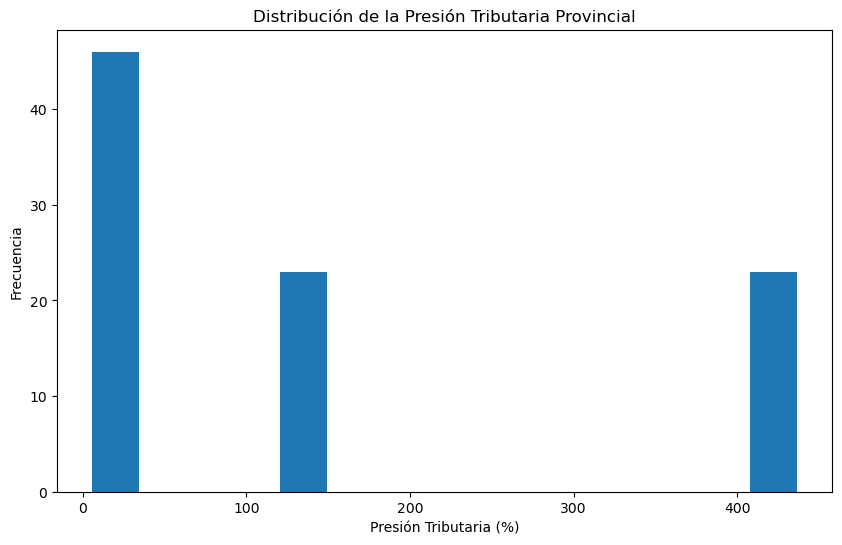

In [16]:
#4️⃣ Distribución de la presión tributaria
#📈 Histograma
plt.hist(df["presion_tributaria"], bins=15)
plt.xlabel("Presión Tributaria (%)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la Presión Tributaria Provincial")
plt.show()


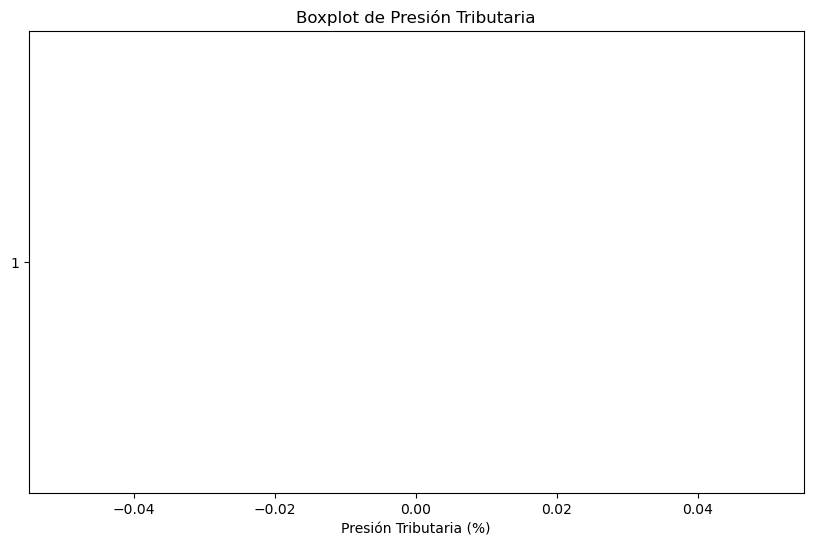

In [18]:
#📦 Boxplot general
plt.boxplot(df["presion_tributaria"], vert=False)
plt.xlabel("Presión Tributaria (%)")
plt.title("Boxplot de Presión Tributaria")
plt.show()

5️⃣ Presión tributaria por provincia

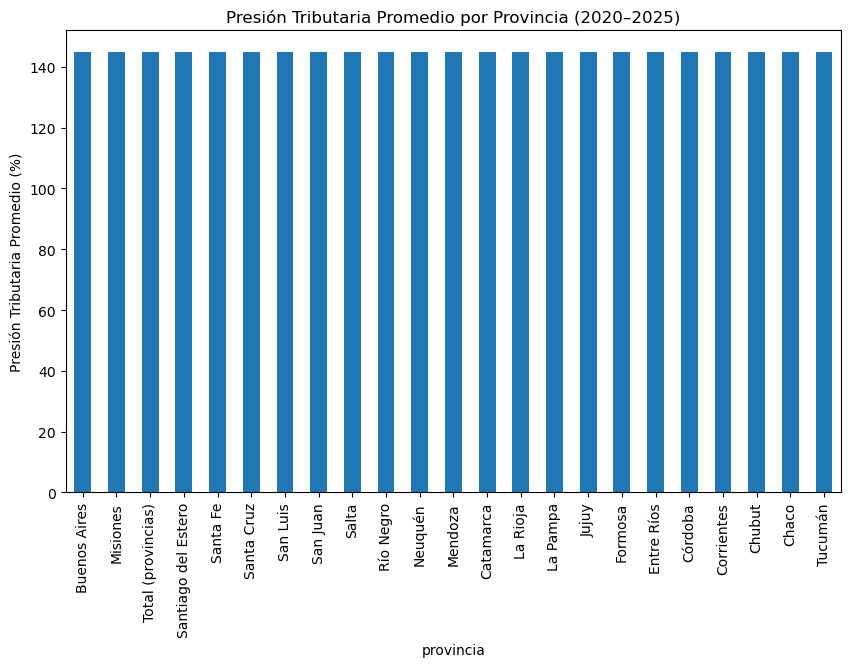

In [21]:
#📊 Promedio por provincia
presion_prov = (
    df.groupby("provincia")["presion_tributaria"]
    .mean()
    .sort_values(ascending=False)
)

presion_prov.plot(kind="bar")
plt.ylabel("Presión Tributaria Promedio (%)")
plt.title("Presión Tributaria Promedio por Provincia (2020–2025)")
plt.show()


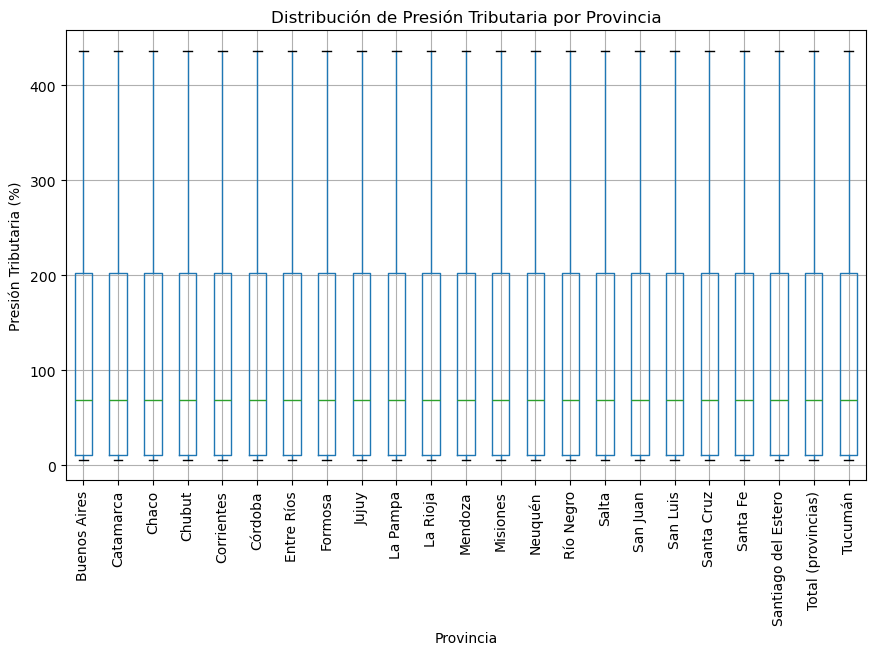

In [23]:
#📦 Boxplot por provincia
df.boxplot(column="presion_tributaria", by="provincia", rot=90)
plt.xlabel("Provincia")
plt.ylabel("Presión Tributaria (%)")
plt.title("Distribución de Presión Tributaria por Provincia")
plt.suptitle("")
plt.show()


6️⃣ Evolución temporal de la presión tributaria

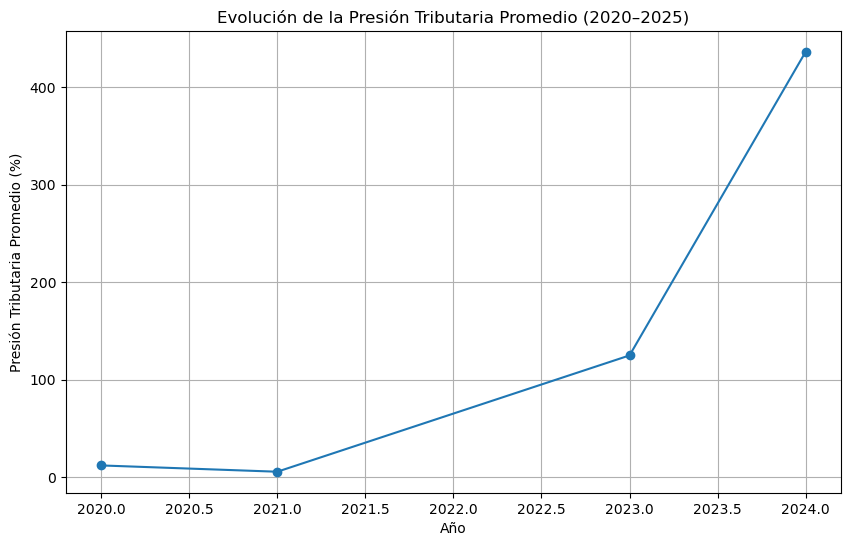

In [26]:
#📈 Promedio país por año
presion_anual = df.groupby("anio")["presion_tributaria"].mean()

plt.plot(presion_anual.index, presion_anual.values, marker="o")
plt.xlabel("Año")
plt.ylabel("Presión Tributaria Promedio (%)")
plt.title("Evolución de la Presión Tributaria Promedio (2020–2025)")
plt.grid(True)
plt.show()

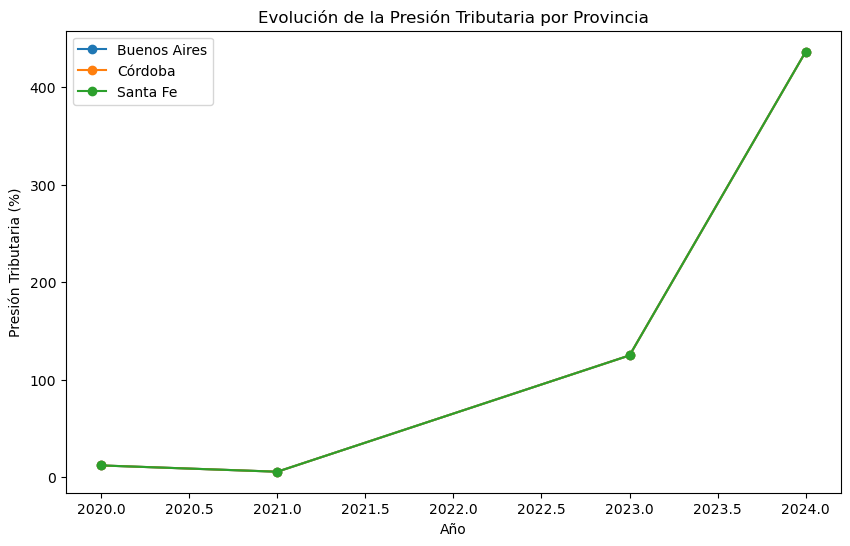

In [38]:
#📈 Evolución por provincias seleccionadas
# Provincias seleccionadas
provincias_sel = ["Buenos Aires", "Córdoba", "Santa Fe"]

for prov in provincias_sel:
    data = df[df["provincia"] == prov]
    plt.plot(data["anio"], data["presion_tributaria"], marker="o", label=prov)

plt.xlabel("Año")
plt.ylabel("Presión Tributaria (%)")
plt.title("Evolución de la Presión Tributaria por Provincia")
plt.legend()
plt.show()



7️⃣ Relación presión tributaria ↔ empleo formal

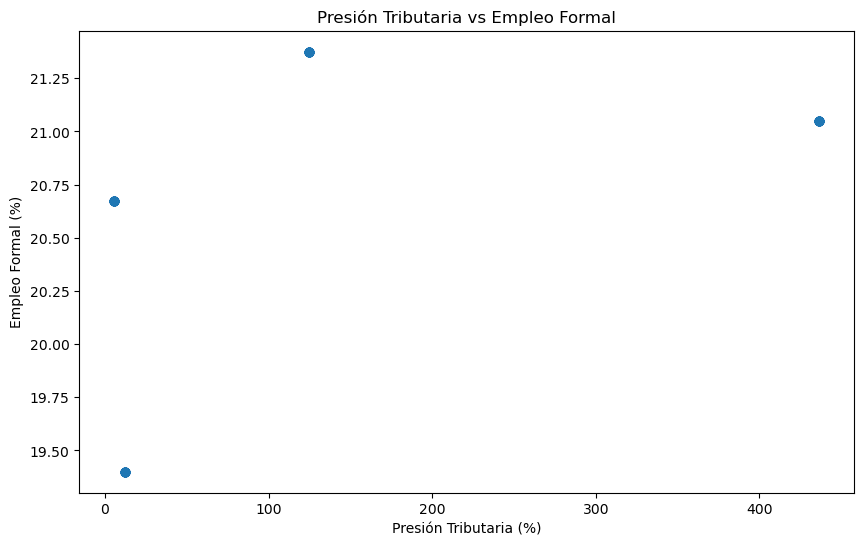

In [43]:
#🔵 Scatter plot
plt.scatter(df["presion_tributaria"], df["tasa_empleo_formal"])
plt.xlabel("Presión Tributaria (%)")
plt.ylabel("Empleo Formal (%)")
plt.title("Presión Tributaria vs Empleo Formal")
plt.show()

In [47]:
#📐 Correlación
corr = df["presion_tributaria"].corr(df["tasa_empleo_formal"])
corr

0.5046896873219443

8️⃣ Presión tributaria y PBI provincial

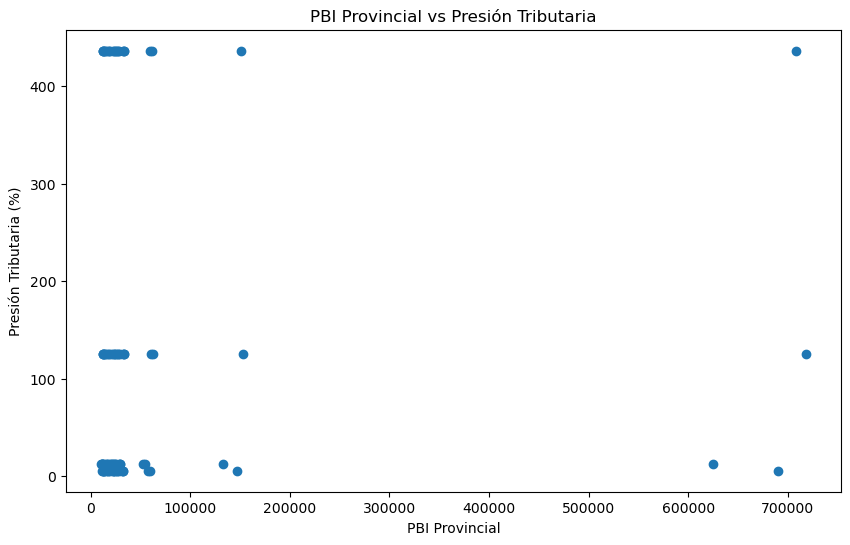

In [50]:
plt.scatter(df["pbi_provincial"], df["presion_tributaria"])
plt.xlabel("PBI Provincial")
plt.ylabel("Presión Tributaria (%)")
plt.title("PBI Provincial vs Presión Tributaria")
plt.show()

9️⃣ Recaudación y estructura impositiva

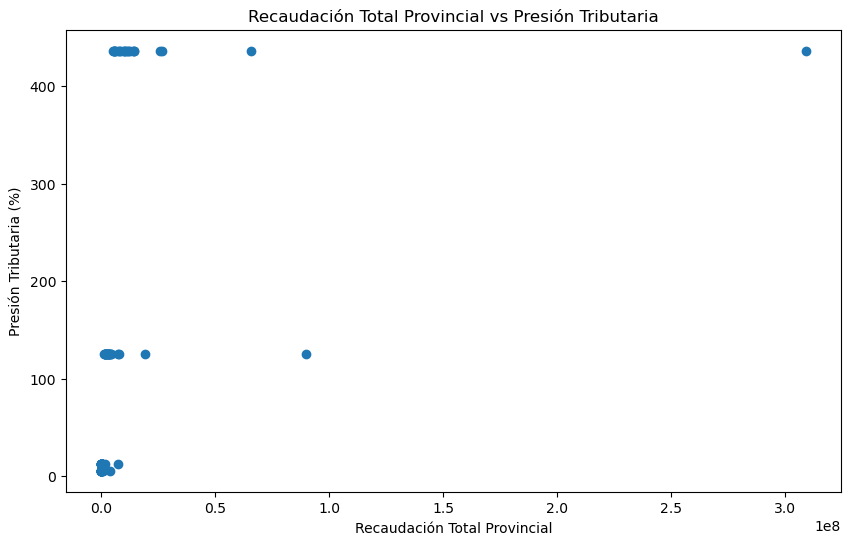

In [57]:
df_rec = df.dropna(subset=["presion_tributaria"])

plt.scatter(
    df_rec["recaudacion_total_prov"],
    df_rec["presion_tributaria"]
)

plt.xlabel("Recaudación Total Provincial")
plt.ylabel("Presión Tributaria (%)")
plt.title("Recaudación Total Provincial vs Presión Tributaria")
plt.show()


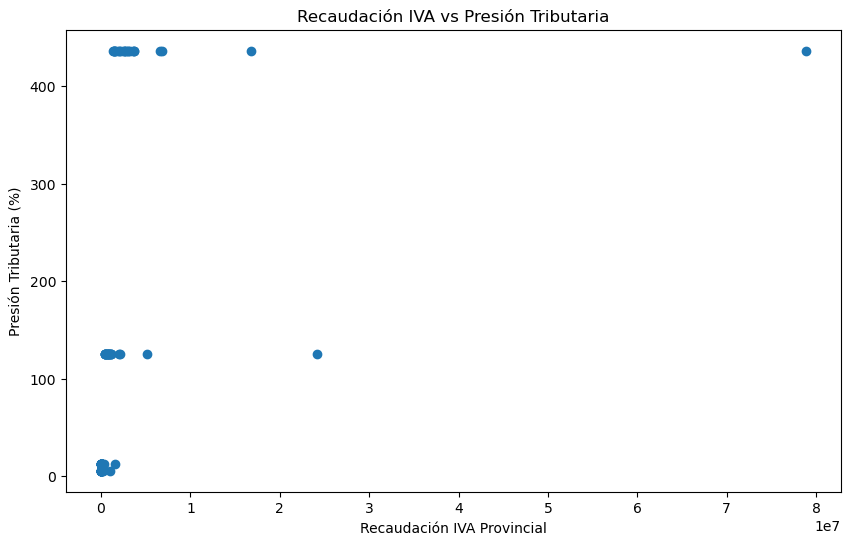

In [59]:
#Estructura impositiva (usando tu dataset real)
plt.scatter(
    df_rec["recaudacion_iva_prov"],
    df_rec["presion_tributaria"]
)

plt.xlabel("Recaudación IVA Provincial")
plt.ylabel("Presión Tributaria (%)")
plt.title("Recaudación IVA vs Presión Tributaria")
plt.show()


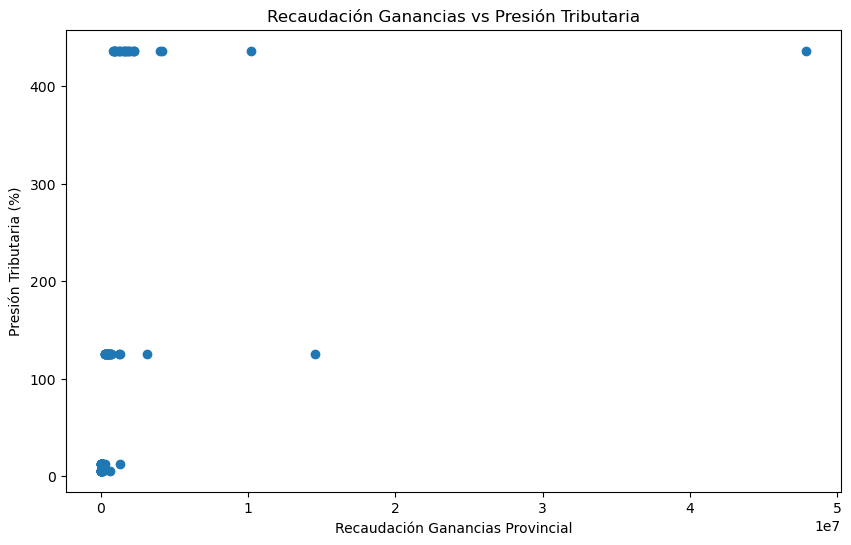

In [61]:
#Ganancias vs presión tributaria
plt.scatter(
    df_rec["recaudacion_ganancias_prov"],
    df_rec["presion_tributaria"]
)

plt.xlabel("Recaudación Ganancias Provincial")
plt.ylabel("Presión Tributaria (%)")
plt.title("Recaudación Ganancias vs Presión Tributaria")
plt.show()
